# Additional Analysis For Chapter 4 of Thesis <br>
Analysing the performance of rreliability (probability) prediction. <br>
Based on the latest results after running fanet_nn_bn_test_02042024.py

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

## Get Mean and Max Abs Err

In [ ]:
LIST = ["/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/Results_NP100000_DJISpark_Downlink_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/Results_NP100000_DJISpark_Uplink_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/Results_NP100000_DJISpark_Video_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJIMavicAir/Results_NP100000_DJIMavicAir_Downlink_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJIMavicAir/Results_NP100000_DJIMavicAir_Uplink_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJIMavicAir/Results_NP100000_DJIMavicAir_Video_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_ParrotAR2/Results_NP100000_ParrotAR2_Downlink_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_ParrotAR2/Results_NP100000_ParrotAR2_Uplink_Reliability.csv", 
        "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_ParrotAR2/Results_NP100000_ParrotAR2_Video_Reliability.csv"]

csv = []
csv_90 = []
csv_99 = []
csv_999 = []

for path in LIST:
    test_results = pd.read_csv(path)

    bn_abs_err = np.abs(test_results["Reliability"] - test_results["BN_Predicted_Reliability"])
    nn_abs_err = np.abs(test_results["Reliability"] - test_results["NN_Predicted_Reliability"])
    mean_abs_err_bn = np.mean(bn_abs_err)
    mean_abs_err_nn = np.mean(nn_abs_err)
    max_abs_err_bn = np.max(bn_abs_err)
    max_abs_err_nn = np.max(nn_abs_err)

    # When Reliability >= 0.9
    rel_90 = test_results.loc[test_results["Reliability"]>=0.9]
    bn_abs_err = np.abs(rel_90["Reliability"] - rel_90["BN_Predicted_Reliability"])
    nn_abs_err = np.abs(rel_90["Reliability"] - rel_90["NN_Predicted_Reliability"])
    mean_abs_err_bn_90 = np.mean(bn_abs_err)
    mean_abs_err_nn_90 = np.mean(nn_abs_err)
    max_abs_err_bn_90 = np.max(bn_abs_err)
    max_abs_err_nn_90 = np.max(nn_abs_err)

    # When Reliability >= 0.99
    rel_99 = test_results.loc[test_results["Reliability"]>=0.99]
    bn_abs_err = np.abs(rel_99["Reliability"] - rel_99["BN_Predicted_Reliability"])
    nn_abs_err = np.abs(rel_99["Reliability"] - rel_99["NN_Predicted_Reliability"])
    mean_abs_err_bn_99 = np.mean(bn_abs_err)
    mean_abs_err_nn_99 = np.mean(nn_abs_err)
    max_abs_err_bn_99 = np.max(bn_abs_err)
    max_abs_err_nn_99 = np.max(nn_abs_err)

    # When Reliability >= 0.999
    rel_999 = test_results.loc[test_results["Reliability"]>=0.999]
    bn_abs_err = np.abs(rel_999["Reliability"] - rel_999["BN_Predicted_Reliability"])
    nn_abs_err = np.abs(rel_999["Reliability"] - rel_999["NN_Predicted_Reliability"])
    mean_abs_err_bn_999 = np.mean(bn_abs_err)
    mean_abs_err_nn_999 = np.mean(nn_abs_err)
    max_abs_err_bn_999 = np.max(bn_abs_err)
    max_abs_err_nn_999 = np.max(nn_abs_err)

    csv.append({"MeanAE_BN": mean_abs_err_bn, "MaxAE_BN": max_abs_err_bn, "MeanAE_NN": mean_abs_err_nn, "MaxAE_NN": max_abs_err_nn})
    csv_90.append({"MeanAE_BN": mean_abs_err_bn_90, "MaxAE_BN": max_abs_err_bn_90, "MeanAE_NN": mean_abs_err_nn_90, "MaxAE_NN": max_abs_err_nn_90})
    csv_99.append({"MeanAE_BN": mean_abs_err_bn_99, "MaxAE_BN": max_abs_err_bn_99, "MeanAE_NN": mean_abs_err_nn_99, "MaxAE_NN": max_abs_err_nn_99})
    csv_999.append({"MeanAE_BN": mean_abs_err_bn_999, "MaxAE_BN": max_abs_err_bn_999, "MeanAE_NN": mean_abs_err_nn_999, "MaxAE_NN": max_abs_err_nn_999})

csv = pd.DataFrame(csv)
csv_90 = pd.DataFrame(csv_90)
csv_99 = pd.DataFrame(csv_99)
csv_999 = pd.DataFrame(csv_999)
csv.to_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/csv.csv")
csv_90.to_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/csv_90.csv")
csv_99.to_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/csv_99.csv")
csv_999.to_csv("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/csv_999.csv")

## Find The Case With Highest Error and Plot

In [92]:
# test_results = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/Results_NP100000_DJISpark_Video_Reliability.csv")
# test_results = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJIMavicAir/Results_NP100000_DJIMavicAir_Video_Reliability.csv")
test_results = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_ParrotAR2/Results_NP100000_ParrotAR2_Uplink_Reliability.csv")

bn_abs_err = np.abs(test_results["Reliability"] - test_results["BN_Predicted_Reliability"])
nn_abs_err = np.abs(test_results["Reliability"] - test_results["NN_Predicted_Reliability"])
max_abs_err_bn = np.max(bn_abs_err)
max_abs_err_nn = np.max(nn_abs_err)
bn_max_idx = np.argmax(bn_abs_err)
nn_max_idx = np.argmax(nn_abs_err)

-1.0 58.5 135.0


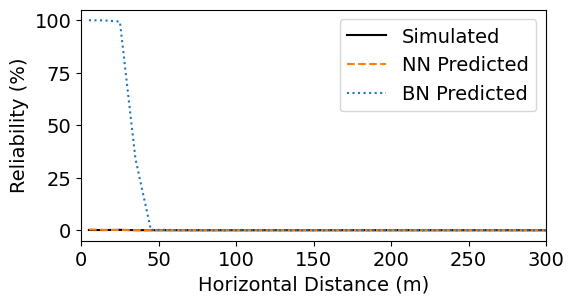

In [98]:
# Plot for BN
bn_row_maxae = test_results.loc[bn_max_idx]

usi = bn_row_maxae.UAV_Sending_Interval
bitrate = bn_row_maxae.Bitrate
height = bn_row_maxae.Height

df = test_results.loc[(test_results["UAV_Sending_Interval"]==usi) & (test_results["Bitrate"]==bitrate) & (test_results["Height"]==height)]

plt.figure(figsize=(6,3))
plt.rcParams.update({'font.size': 14})
plt.plot(df["Horizontal_Distance"].values, df["Reliability"].values*100, 'k')
plt.plot(df["Horizontal_Distance"].values, df["NN_Predicted_Reliability"].values*100, '--', color='tab:orange')
plt.plot(df["Horizontal_Distance"].values, df["BN_Predicted_Reliability"].values*100, ':', color='tab:blue')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Reliability (%)")
plt.xlim(0, 300)
plt.legend(["Simulated", "NN Predicted", "BN Predicted"])

plt.savefig("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/Chap_4_fig10a.svg", format="svg", bbox_inches='tight')

print(usi, bitrate, height)

0.5 65.0 165.0


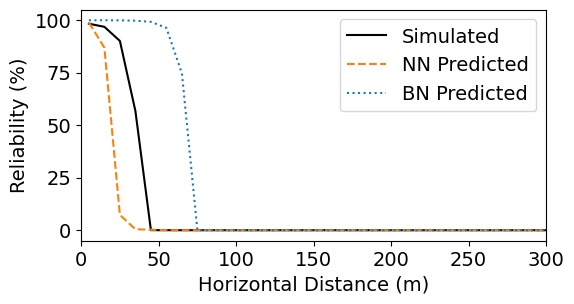

In [99]:
# Plot for NN
nn_row_maxae = test_results.loc[nn_max_idx]

usi = nn_row_maxae.UAV_Sending_Interval
bitrate = nn_row_maxae.Bitrate
height = nn_row_maxae.Height

df = test_results.loc[(test_results["UAV_Sending_Interval"]==usi) & (test_results["Bitrate"]==bitrate) & (test_results["Height"]==height)]

plt.figure(figsize=(6,3))
plt.rcParams.update({'font.size': 14})
plt.plot(df["Horizontal_Distance"].values, df["Reliability"].values*100, 'k')
plt.plot(df["Horizontal_Distance"].values, df["NN_Predicted_Reliability"].values*100, '--', color='tab:orange')
plt.plot(df["Horizontal_Distance"].values, df["BN_Predicted_Reliability"].values*100, ':', color='tab:blue')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Reliability (%)")
plt.xlim(0, 300)
plt.legend(["Simulated", "NN Predicted", "BN Predicted"])

plt.savefig("/home/research-student/omnet-fanet/data-processing-scripts/journal_2_scripts/Chap_4_fig10b.svg", format="svg", bbox_inches='tight')

print(usi, bitrate, height)